In [ ]:
!pip install statsmodels scikit-posthocs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.3 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

data = pd.DataFrame({
    "Group": np.repeat(["Control", "Treatment_A", "Treatment_B"], 40),
    "Score": np.concatenate([
        np.random.normal(70, 8, 40),
        np.random.normal(75, 8, 40),
        np.random.normal(80, 8, 40)
    ]),
    "Gender": np.tile(["Male", "Female"], 60),
    "Age_Group": np.tile(["Young", "Adult"], 60)
})

data.head()

,Group,Score,Gender,Age_Group
0,Control,73.973713,Male,Young
1,Control,68.893886,Female,Adult
2,Control,75.181508,Male,Young
3,Control,82.184239,Female,Adult
4,Control,68.126773,Male,Young


In [ ]:
print("Dataset shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

print("\nGroup counts:")
print(data["Group"].value_counts())

print("\nDescriptive statistics:")
print(data.groupby("Group")["Score"].describe())

Dataset shape: (120, 4)

Missing values:
Group        0
Score        0
Gender       0
Age_Group    0
dtype: int64

Group counts:
Group
Control        40
Treatment_A    40
Treatment_B    40
Name: count, dtype: int64

Descriptive statistics:
             count       mean       std        min        25%        50%  \
Group                                                                      
Control       40.0  68.250905  7.622472  54.322639  62.526193  68.126839   
Treatment_A   40.0  74.767652  7.718141  54.042039  70.834715  75.204884   
Treatment_B   40.0  80.081385  6.896752  64.649830  76.472614  79.755097   

                   75%        max  
Group                              
Control      72.636880  84.818225  
Treatment_A  81.055851  87.517149  
Treatment_B  82.686732  99.705937  


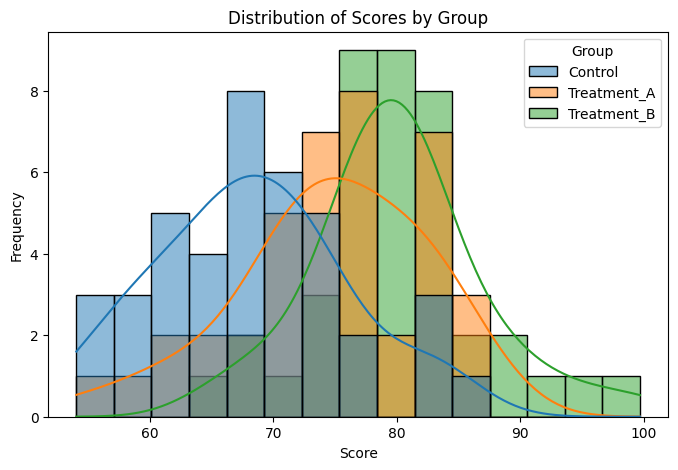

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="Score",
    hue="Group",
    kde=True,
    bins=15
)

plt.title("Distribution of Scores by Group")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
groups = data["Group"].unique()

for group in groups:
    scores = data[data["Group"] == group]["Score"]
    statistic, p_value = stats.shapiro(scores)

    print(f"{group}:")
    print(f"Shapiro-Wilk statistic = {statistic:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("Result: Data is approximately normally distributed.\n")
    else:
        print("Result: Data is not normally distributed.\n")

Control:
Shapiro-Wilk statistic = 0.9792
p-value = 0.6604
Result: Data is approximately normally distributed.

Treatment_A:
Shapiro-Wilk statistic = 0.9704
p-value = 0.3709
Result: Data is approximately normally distributed.

Treatment_B:
Shapiro-Wilk statistic = 0.9687
p-value = 0.3269
Result: Data is approximately normally distributed.



In [ ]:
for group in groups:
    scores = data[data["Group"] == group]["Score"]

    # Standardize the scores before the K-S test
    standardized_scores = (scores - scores.mean()) / scores.std()

    statistic, p_value = stats.kstest(
        standardized_scores,
        "norm"
    )

    print(f"{group}:")
    print(f"Kolmogorov-Smirnov statistic = {statistic:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("Result: Data is approximately normally distributed.\n")
    else:
        print("Result: Data is not normally distributed.\n")

Control:
Kolmogorov-Smirnov statistic = 0.0688
p-value = 0.9847
Result: Data is approximately normally distributed.

Treatment_A:
Kolmogorov-Smirnov statistic = 0.0704
p-value = 0.9807
Result: Data is approximately normally distributed.

Treatment_B:
Kolmogorov-Smirnov statistic = 0.1239
p-value = 0.5307
Result: Data is approximately normally distributed.



In [ ]:
control = data[data["Group"] == "Control"]["Score"]
treatment_a = data[data["Group"] == "Treatment_A"]["Score"]

t_stat, t_pvalue = stats.ttest_ind(
    control,
    treatment_a,
    equal_var=False
)

print("Two-Sample Independent t-test")
print("--------------------------------")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {t_pvalue:.6f}")

if t_pvalue < 0.05:
    print("Result: Statistically significant difference between the groups.")
else:
    print("Result: No statistically significant difference between the groups.")

Two-Sample Independent t-test
--------------------------------
t-statistic = -3.7995
p-value = 0.000286
Result: Statistically significant difference between the groups.


In [ ]:
u_stat, u_pvalue = stats.mannwhitneyu(
    control,
    treatment_a,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("-------------------")
print(f"U-statistic = {u_stat:.4f}")
print(f"p-value = {u_pvalue:.6f}")

if u_pvalue < 0.05:
    print("Result: Statistically significant difference between the groups.")
else:
    print("Result: No statistically significant difference between the groups.")

Mann-Whitney U Test
-------------------
U-statistic = 417.0000
p-value = 0.000233
Result: Statistically significant difference between the groups.


In [ ]:
control = data[data["Group"] == "Control"]["Score"]
treatment_a = data[data["Group"] == "Treatment_A"]["Score"]
treatment_b = data[data["Group"] == "Treatment_B"]["Score"]

f_stat, anova_pvalue = stats.f_oneway(
    control,
    treatment_a,
    treatment_b
)

print("One-Way ANOVA")
print("-------------")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {anova_pvalue:.6f}")

if anova_pvalue < 0.05:
    print("Result: There is a statistically significant difference among the groups.")
else:
    print("Result: No statistically significant difference among the groups.")

One-Way ANOVA
-------------
F-statistic = 25.4984
p-value = 0.000000
Result: There is a statistically significant difference among the groups.


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=data["Score"],
    groups=data["Group"],
    alpha=0.05
)

print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj  lower   upper  reject
-------------------------------------------------------------
    Control Treatment_A   6.5167 0.0004 2.5772 10.4563   True
    Control Treatment_B  11.8305    0.0  7.891   15.77   True
Treatment_A Treatment_B   5.3137  0.005 1.3742  9.2532   True
-------------------------------------------------------------


In [ ]:
model = ols(
    "Score ~ C(Group) + C(Gender) + C(Group):C(Gender)",
    data=data
).fit()

two_way_anova = sm.stats.anova_lm(
    model,
    typ=2
)

print("Two-Way ANOVA")
print("-------------")
print(two_way_anova)

Two-Way ANOVA
-------------
                         sum_sq     df          F        PR(>F)
C(Group)            2808.853339    2.0  25.075969  9.430915e-10
C(Gender)             16.157558    1.0   0.288492  5.922351e-01
C(Group):C(Gender)    43.300056    2.0   0.386560  6.802769e-01
Residual            6384.783898  114.0        NaN           NaN


In [ ]:
confidence_level = 0.95

summary = data.groupby("Group")["Score"].agg(
    ["count", "mean", "std"]
)

summary["SE"] = summary["std"] / np.sqrt(summary["count"])

summary["CI_lower"] = (
    summary["mean"] -
    stats.t.ppf(0.975, summary["count"] - 1) * summary["SE"]
)

summary["CI_upper"] = (
    summary["mean"] +
    stats.t.ppf(0.975, summary["count"] - 1) * summary["SE"]
)

print("95% Confidence Intervals")
print("------------------------")
print(summary.round(3))

95% Confidence Intervals
------------------------
             count    mean    std     SE  CI_lower  CI_upper
Group                                                       
Control         40  68.251  7.622  1.205    65.813    70.689
Treatment_A     40  74.768  7.718  1.220    72.299    77.236
Treatment_B     40  80.081  6.897  1.090    77.876    82.287


In [ ]:
Hypotheses for Statistical Tests

## 1. Shapiro-Wilk Normality Test
- Null Hypothesis (H₀): The data is normally distributed.
- Alternative Hypothesis (H₁): The data is not normally distributed.
- Decision rule: If p < 0.05, reject H₀.

## 2. Kolmogorov-Smirnov Normality Test
- Null Hypothesis (H₀): The sample follows a normal distribution.
- Alternative Hypothesis (H₁): The sample does not follow a normal distribution.
- Decision rule: If p < 0.05, reject H₀.

## 3. Independent Two-Sample t-Test
- Null Hypothesis (H₀): There is no significant difference in mean scores between Control and Treatment_A groups.
- Alternative Hypothesis (H₁): There is a significant difference in mean scores between Control and Treatment_A groups.
- Decision rule: If p < 0.05, reject H₀.

## 4. Mann-Whitney U Test
- Null Hypothesis (H₀): There is no significant difference between the distributions of Control and Treatment_A groups.
- Alternative Hypothesis (H₁): There is a significant difference between the distributions of the two groups.
- Decision rule: If p < 0.05, reject H₀.

## 5. One-Way ANOVA
- Null Hypothesis (H₀): The mean scores of Control, Treatment_A, and Treatment_B are equal.
- Alternative Hypothesis (H₁): At least one group mean is significantly different.
- Decision rule: If p < 0.05, reject H₀.

## 6. Two-Way ANOVA
- Null Hypothesis (H₀): Group, Gender, and their interaction have no significant effect on Score.
- Alternative Hypothesis (H₁): At least one factor or their interaction has a significant effect on Score.
- Decision rule: If p < 0.05, reject H₀.

In [ ]:
tukey = pairwise_tukeyhsd(
    endog=data["Score"],
    groups=data["Group"],
    alpha=0.05
)

print("Tukey HSD Post-Hoc Analysis")
print("---------------------------")
print(tukey)

Tukey HSD Post-Hoc Analysis
---------------------------
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj  lower   upper  reject
-------------------------------------------------------------
    Control Treatment_A   6.5167 0.0004 2.5772 10.4563   True
    Control Treatment_B  11.8305    0.0  7.891   15.77   True
Treatment_A Treatment_B   5.3137  0.005 1.3742  9.2532   True
-------------------------------------------------------------


In [ ]:
Final Findings and Conclusions

Normality Tests

The Shapiro-Wilk and Kolmogorov-Smirnov tests showed p-values greater than 0.05 for all three groups. Therefore, the null hypothesis was not rejected, indicating that the score distributions are approximately normally distributed.

Independent t-Test

The independent two-sample t-test between Control and Treatment_A produced a p-value of 0.000286. Since p < 0.05, the null hypothesis was rejected. There is a statistically significant difference between the two groups.

Mann-Whitney U Test

The Mann-Whitney U test produced a p-value of 0.000233. Since p < 0.05, the null hypothesis was rejected. There is a statistically significant difference between the Control and Treatment_A groups.

One-Way ANOVA

The One-Way ANOVA produced an F-statistic of 25.4984 with p < 0.05. Therefore, the null hypothesis was rejected, indicating a statistically significant difference among the three groups.

Tukey HSD Post-Hoc Analysis

Tukey HSD showed statistically significant differences in all pairwise comparisons:

- Control vs Treatment_A: p = 0.0004
- Control vs Treatment_B: p < 0.001
- Treatment_A vs Treatment_B: p = 0.005

Two-Way ANOVA

The Group factor had a statistically significant effect on Score (p < 0.05).

Gender did not have a statistically significant effect on Score (p = 0.5922).

The Group × Gender interaction was not statistically significant (p = 0.6803).

95% Confidence Intervals

The estimated mean score and 95% confidence intervals were:

- Control: Mean = 68.251, 95% CI = 65.813 to 70.689
- Treatment_A: Mean = 74.768, 95% CI = 72.299 to 77.236
- Treatment_B: Mean = 80.081, 95% CI = 77.876 to 82.287

Overall Conclusion

The statistical analysis indicates that the three groups have significantly different score levels. Treatment_B has the highest mean score, followed by Treatment_A and Control. The results are supported by the t-test, Mann-Whitney U test, One-Way ANOVA, and Tukey HSD post-hoc analysis. Gender and the Group × Gender interaction were not statistically significant.

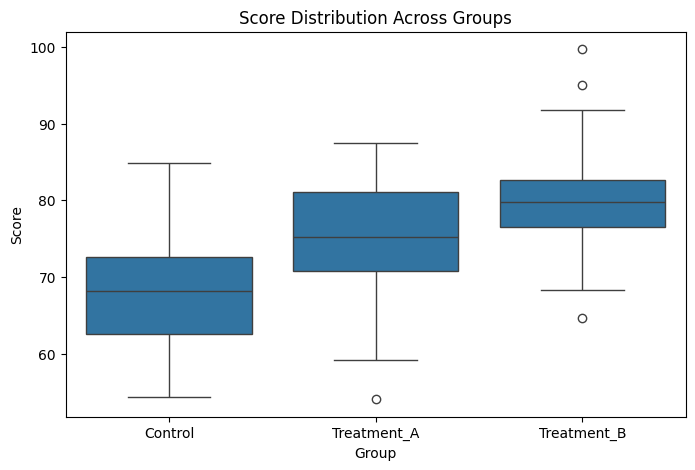

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Group",
    y="Score"
)

plt.title("Score Distribution Across Groups")
plt.xlabel("Group")
plt.ylabel("Score")
plt.show()